# 01 — Exploratory Data Analysis
**CamAgri Agricultural Risk Assessment Platform**

This notebook performs comprehensive EDA across all four dataset types:
- `data/prices/{crop}_price.csv` — weekly market prices per crop per region
- `data/yields/cameroon_yields.csv` — farm-level yield observations
- `data/soil/cameroon_soil.csv` — soil characteristics by GPS coordinates
- `data/climate/cameroon_climate.csv` — monthly climate indicators by region

**Sections**
1. Setup & data loading
2. Price data EDA
3. Yield data EDA
4. Soil data EDA
5. Climate data EDA
6. Cross-dataset correlations
7. Key findings summary

## 1. Setup & Data Loading

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import kurtosis, skew

warnings.filterwarnings('ignore')

# ── Paths (adjust DATA_ROOT to your project root) ──────────────────────────
DATA_ROOT   = Path('../data')            # change if needed
PRICES_DIR  = DATA_ROOT / 'prices'
YIELDS_PATH = DATA_ROOT / 'yields' / 'cameroon_yields.csv'
SOIL_PATH   = DATA_ROOT / 'soil'   / 'cameroon_soil.csv'
CLIMATE_PATH= DATA_ROOT / 'climate'/ 'cameroon_climate.csv'
OUTPUT_DIR  = Path('../outputs/eda')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d0d0d',
    'axes.facecolor':   '#111111',
    'axes.edgecolor':   '#333333',
    'axes.labelcolor':  '#cccccc',
    'axes.titlecolor':  '#ffffff',
    'text.color':       '#cccccc',
    'xtick.color':      '#666666',
    'ytick.color':      '#666666',
    'grid.color':       '#222222',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'figure.titlesize': 15,
    'figure.titleweight': 'bold',
})
LIME    = '#CAFF00'
PALETTE = ['#CAFF00','#00CFFF','#FF6B6B','#FFB800','#A78BFA','#34D399','#FB923C','#F472B6']
sns.set_palette(PALETTE)

CROPS   = ['maize','rice','cassava','cocoyam','plantain','cocoa','coffee',
           'groundnut','beans','tomato','onion','potato','palm_oil','sorghum']
REGIONS = ['North West','South West','West','Littoral','Adamawa',
           'Far North','Centre','East','North','South']

print('Setup complete.')

Setup complete.


In [28]:
# ── Load all price CSVs into a single combined DataFrame ───────────────────
price_frames = []
for csv in sorted(PRICES_DIR.glob('*_price.csv')):
    df = pd.read_csv(csv, parse_dates=['date'])
    price_frames.append(df)

prices = pd.concat(price_frames, ignore_index=True)
prices['date'] = pd.to_datetime(prices['date'])

# ── Load other datasets ────────────────────────────────────────────────────
yields  = pd.read_csv(YIELDS_PATH)
soil    = pd.read_csv(SOIL_PATH)
climate = pd.read_csv(CLIMATE_PATH)

print(f'Prices  : {prices.shape}  |  date range: {prices.date.min().date()} → {prices.date.max().date()}')
print(f'Yields  : {yields.shape}')
print(f'Soil    : {soil.shape}')
print(f'Climate : {climate.shape}')

Prices  : (58240, 7)  |  date range: 2016-01-01 → 2023-12-15
Yields  : (3000, 13)
Soil    : (1000, 11)
Climate : (540, 8)


## 2. Price Data EDA

In [24]:
# ── 2.1 Schema & basic stats ───────────────────────────────────────────────
print('=== PRICE DATA SCHEMA ===')
print(prices.dtypes)
print()
print('=== MISSING VALUES ===')
print(prices.isnull().sum())
print()
print('=== DESCRIPTIVE STATISTICS (price_xaf_per_kg) ===')
print(prices['price_xaf_per_kg'].describe().round(2))
print()
print('=== UNIQUE COUNTS ===')
for col in ['crop','region','season','year']:
    print(f'  {col}: {prices[col].nunique()} unique → {sorted(prices[col].unique())[:5]}...')

=== PRICE DATA SCHEMA ===
date                datetime64[ns]
price_xaf_per_kg           float64
region                      object
crop                        object
year                         int64
month                        int64
week                         int64
dtype: object

=== MISSING VALUES ===
date                0
price_xaf_per_kg    0
region              0
crop                0
year                0
month               0
week                0
dtype: int64

=== DESCRIPTIVE STATISTICS (price_xaf_per_kg) ===
count    58240.00
mean       549.61
std        417.40
min         76.00
25%        221.00
50%        402.00
75%        793.00
max       2310.00
Name: price_xaf_per_kg, dtype: float64

=== UNIQUE COUNTS ===
  crop: 14 unique → ['beans', 'cassava', 'cocoa', 'cocoyam', 'coffee']...
  region: 10 unique → ['Adamawa', 'Centre', 'East', 'Far North', 'Littoral']...


KeyError: 'season'

In [5]:
# ── 2.2 National average price per crop ───────────────────────────────────
crop_stats = (
    prices.groupby('crop')['price_xaf_per_kg']
    .agg(mean='mean', median='median', std='std', cv=lambda x: x.std()/x.mean()*100)
    .round(2)
    .sort_values('mean', ascending=False)
)
print('=== PRICE STATISTICS BY CROP (XAF/kg) ===')
print(crop_stats.to_string())

=== PRICE STATISTICS BY CROP (XAF/kg) ===
              mean  median     std     cv
crop                                     
cocoa      1451.81  1445.0  252.05  17.36
palm_oil   1164.96  1145.0  169.56  14.55
coffee     1021.84  1017.0  190.25  18.62
beans       764.36   756.5  188.60  24.67
groundnut   650.58   638.0  132.51  20.37
rice        515.19   511.0   85.53  16.60
onion       439.58   436.0  148.38  33.75
tomato      344.55   337.0  148.38  43.07
potato      310.15   309.0   78.47  25.30
maize       274.78   273.0   67.88  24.70
sorghum     237.70   233.0   51.37  21.61
cocoyam     220.01   217.0   48.17  21.89
plantain    170.12   171.0   53.80  31.62
cassava     128.92   128.0   23.60  18.31


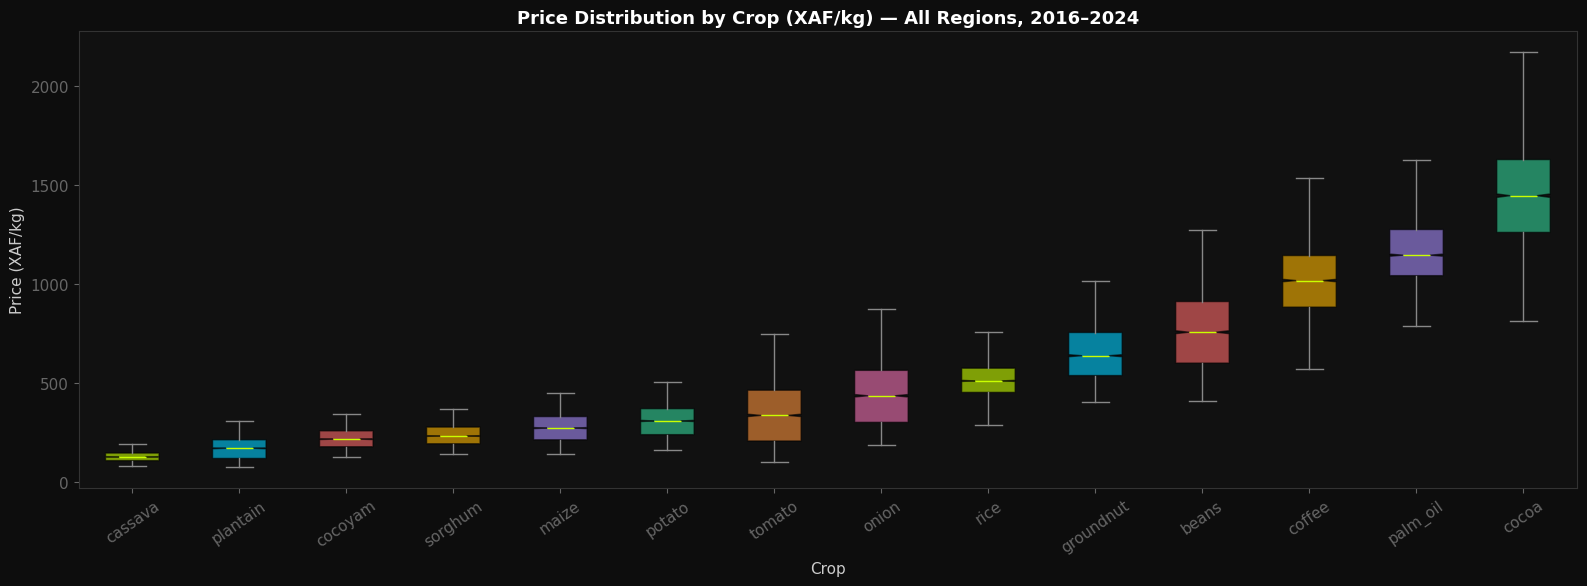

In [6]:
# ── 2.3 Price distribution by crop (box plots) ────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
order = prices.groupby('crop')['price_xaf_per_kg'].median().sort_values().index
bp = ax.boxplot(
    [prices.loc[prices.crop==c,'price_xaf_per_kg'].values for c in order],
    labels=order, patch_artist=True, notch=True, showfliers=False,
)
for patch, color in zip(bp['boxes'], PALETTE * 2):
    patch.set_facecolor(color); patch.set_alpha(0.6)
for element in ['whiskers','caps','medians']:
    for line in bp[element]: line.set_color('#888888' if element!='medians' else LIME)
ax.set_title('Price Distribution by Crop (XAF/kg) — All Regions, 2016–2024')
ax.set_xlabel('Crop'); ax.set_ylabel('Price (XAF/kg)')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'price_distribution_by_crop.png', dpi=140, bbox_inches='tight')
plt.show()

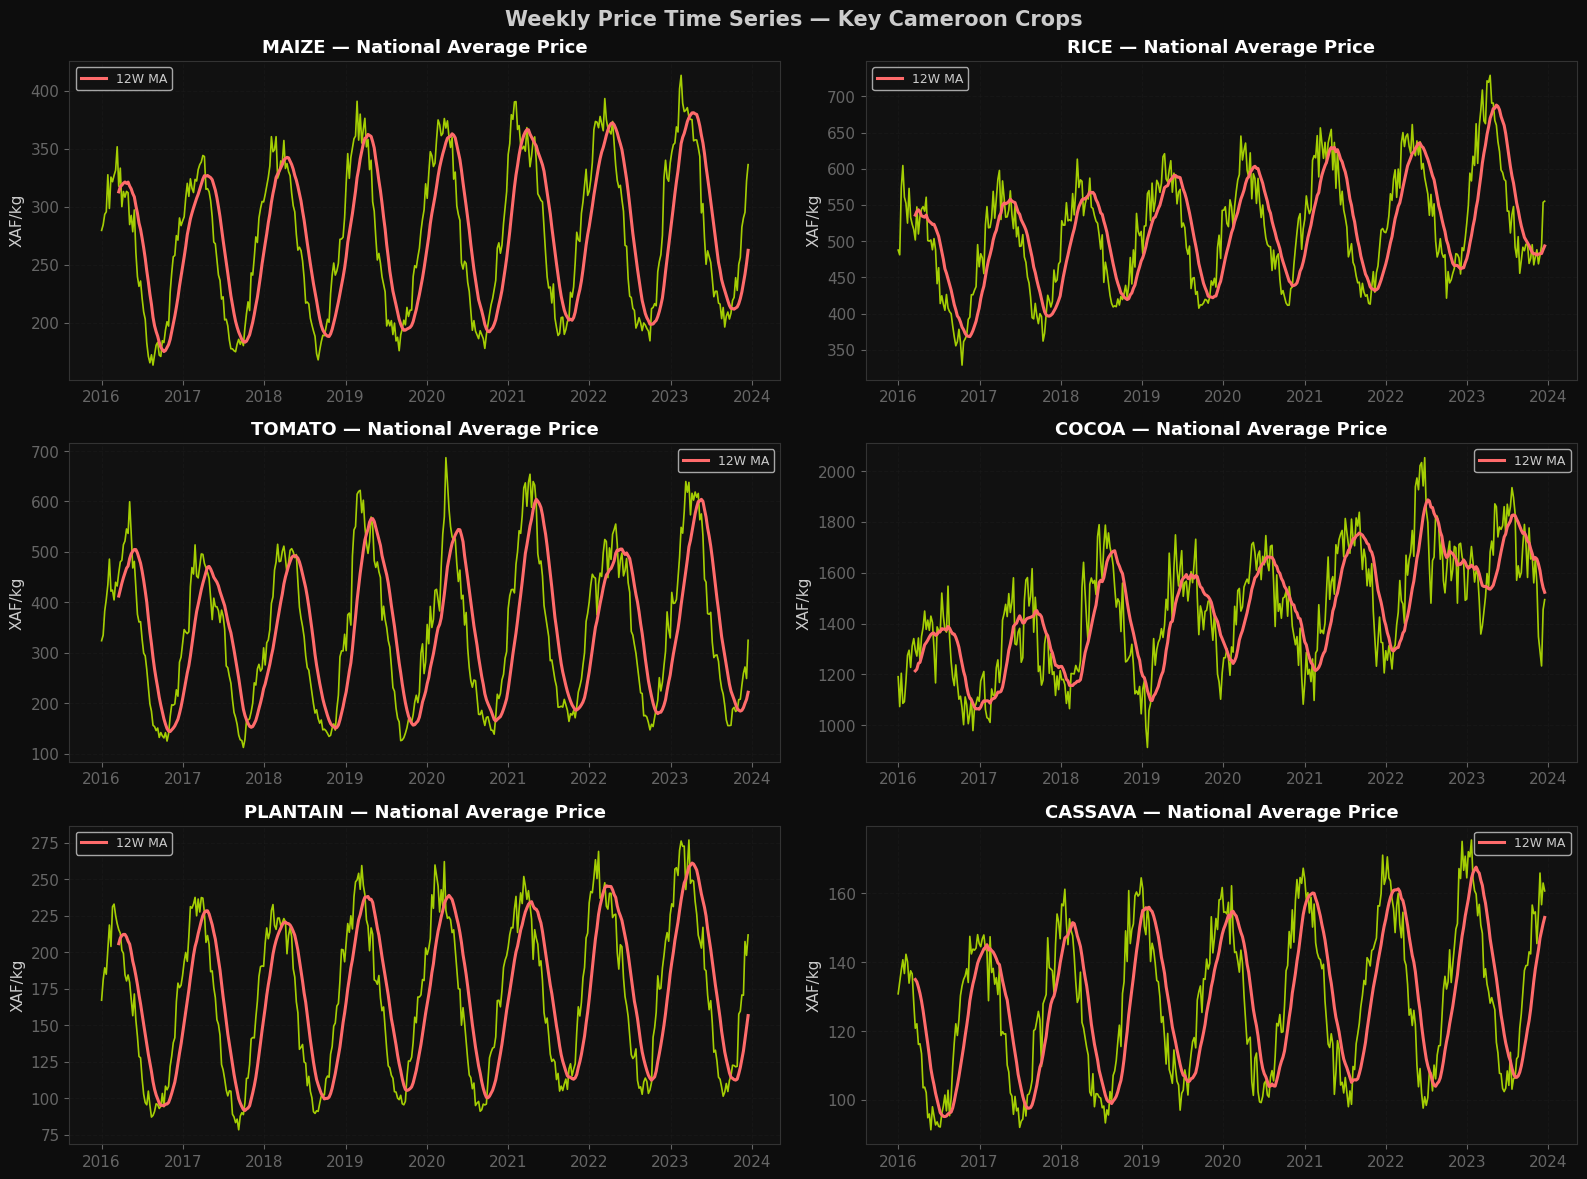

In [7]:
# ── 2.4 Price time series for key crops ───────────────────────────────────
KEY_CROPS = ['maize','rice','tomato','cocoa','plantain','cassava']
national_weekly = (
    prices.groupby(['date','crop'])['price_xaf_per_kg']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
for ax, crop in zip(axes.flat, KEY_CROPS):
    df = national_weekly[national_weekly.crop == crop].set_index('date')
    ax.plot(df.index, df['price_xaf_per_kg'], color=LIME, lw=1.2, alpha=0.8)
    # 12-week rolling average
    ax.plot(df.index, df['price_xaf_per_kg'].rolling(12).mean(),
            color='#FF6B6B', lw=2.2, label='12W MA')
    ax.set_title(f'{crop.upper()} — National Average Price')
    ax.set_ylabel('XAF/kg'); ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
fig.suptitle('Weekly Price Time Series — Key Cameroon Crops', fontsize=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'price_timeseries.png', dpi=140, bbox_inches='tight')
plt.show()

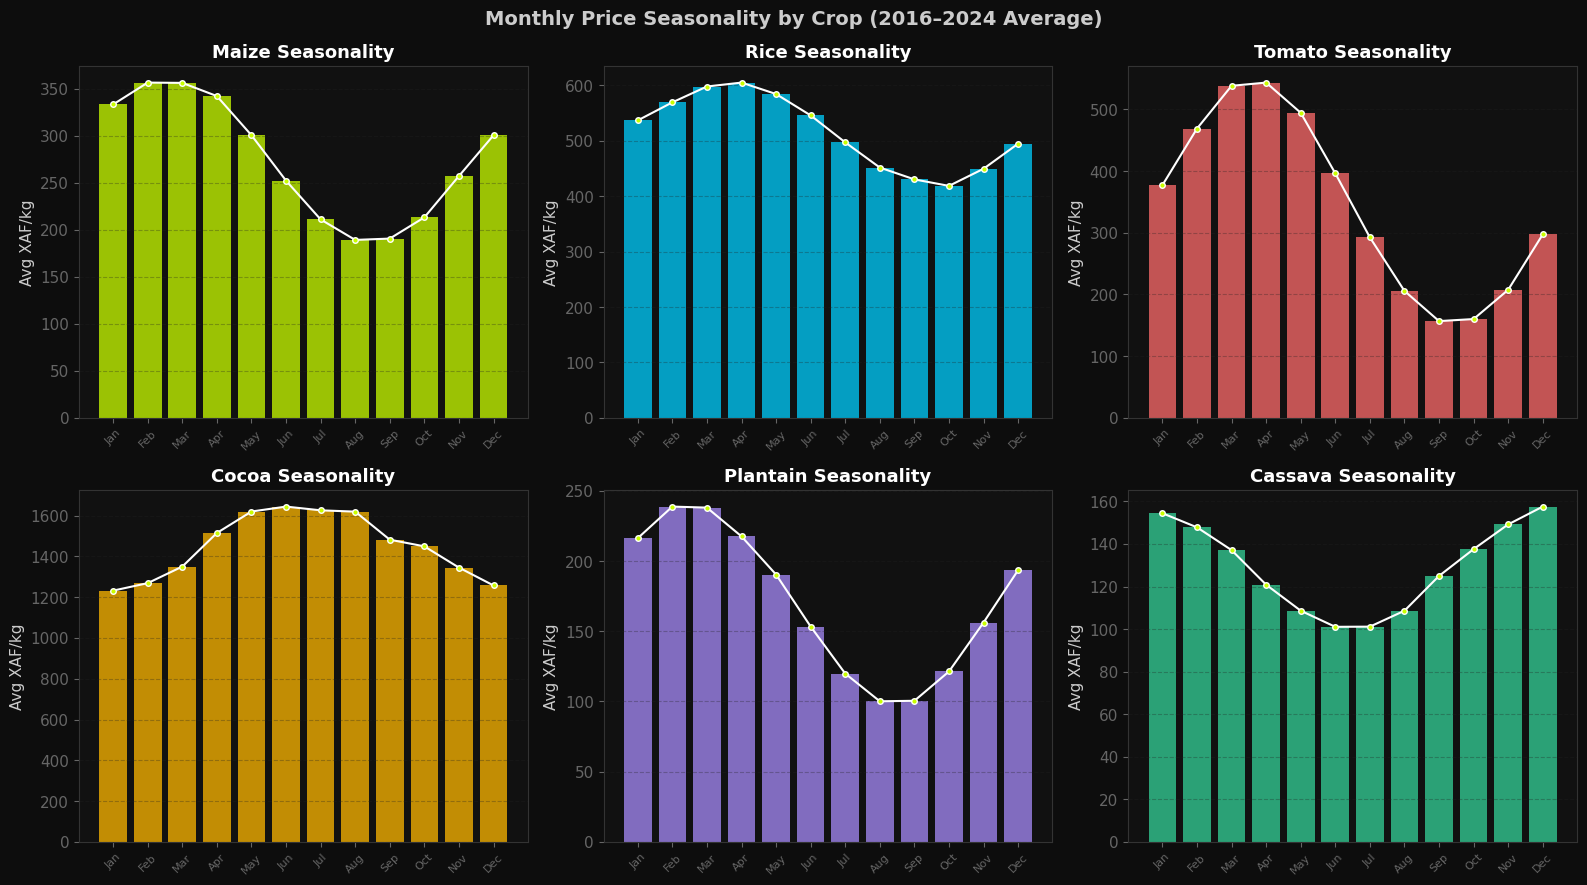

In [8]:
# ── 2.5 Seasonality analysis — average price by month ─────────────────────
monthly_avg = (
    prices[prices.crop.isin(KEY_CROPS)]
    .groupby(['crop','month'])['price_xaf_per_kg']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for ax, (crop, c) in zip(axes.flat, zip(KEY_CROPS, PALETTE)):
    df = monthly_avg[monthly_avg.crop == crop]
    ax.bar(df.month, df.price_xaf_per_kg, color=c, alpha=0.75, edgecolor='none')
    ax.plot(df.month, df.price_xaf_per_kg, color='white', lw=1.5, marker='o',
            markersize=4, markerfacecolor=LIME)
    ax.set_xticks(range(1,13)); ax.set_xticklabels(month_labels, rotation=45, fontsize=8)
    ax.set_title(f'{crop.capitalize()} Seasonality')
    ax.set_ylabel('Avg XAF/kg'); ax.grid(True, axis='y', alpha=0.3)
fig.suptitle('Monthly Price Seasonality by Crop (2016–2024 Average)', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'price_seasonality.png', dpi=140, bbox_inches='tight')
plt.show()

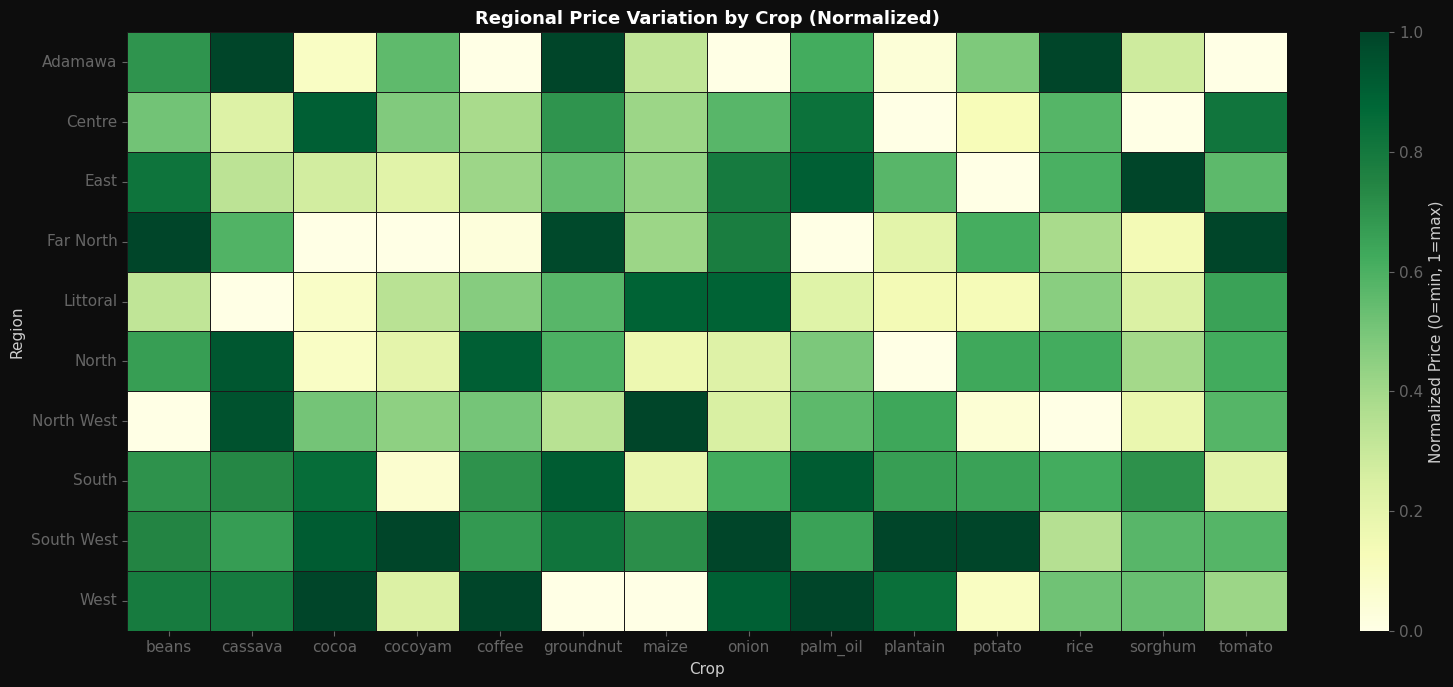


Regions with HIGHEST average prices per crop:
crop
beans         Far North
cassava         Adamawa
cocoa              West
cocoyam      South West
coffee             West
groundnut       Adamawa
maize        North West
onion        South West
palm_oil           West
plantain     South West
potato       South West
rice            Adamawa
sorghum            East
tomato        Far North
dtype: object


In [9]:
# ── 2.6 Regional price variation heatmap ──────────────────────────────────
pivot = (
    prices.groupby(['region','crop'])['price_xaf_per_kg']
    .mean()
    .unstack('crop')
)
# Normalize each crop to [0,1] for visual comparison
pivot_norm = (pivot - pivot.min()) / (pivot.max() - pivot.min())

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    pivot_norm, ax=ax, cmap='YlGn', annot=False,
    linewidths=0.4, linecolor='#1a1a1a',
    cbar_kws={'label': 'Normalized Price (0=min, 1=max)'}
)
ax.set_title('Regional Price Variation by Crop (Normalized)')
ax.set_xlabel('Crop'); ax.set_ylabel('Region')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'price_regional_heatmap.png', dpi=140, bbox_inches='tight')
plt.show()
print('\nRegions with HIGHEST average prices per crop:')
print(pivot.idxmax())

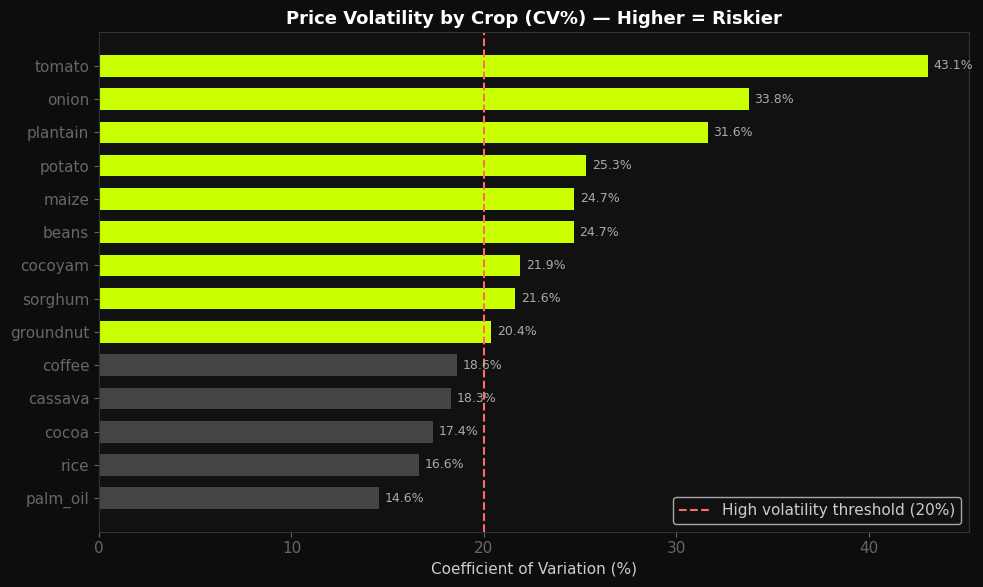

In [10]:
# ── 2.7 Price volatility (coefficient of variation) ───────────────────────
vol = (
    prices.groupby('crop')['price_xaf_per_kg']
    .agg(cv=lambda x: x.std() / x.mean() * 100)
    .sort_values('cv', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(vol.index, vol['cv'],
               color=[LIME if v > 20 else '#444444' for v in vol['cv']],
               edgecolor='none', height=0.65)
ax.axvline(20, color='#FF6B6B', lw=1.5, linestyle='--', label='High volatility threshold (20%)')
ax.set_xlabel('Coefficient of Variation (%)')
ax.set_title('Price Volatility by Crop (CV%) — Higher = Riskier')
ax.legend()
for bar, v in zip(bars, vol['cv']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=9, color='#aaaaaa')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'price_volatility.png', dpi=140, bbox_inches='tight')
plt.show()

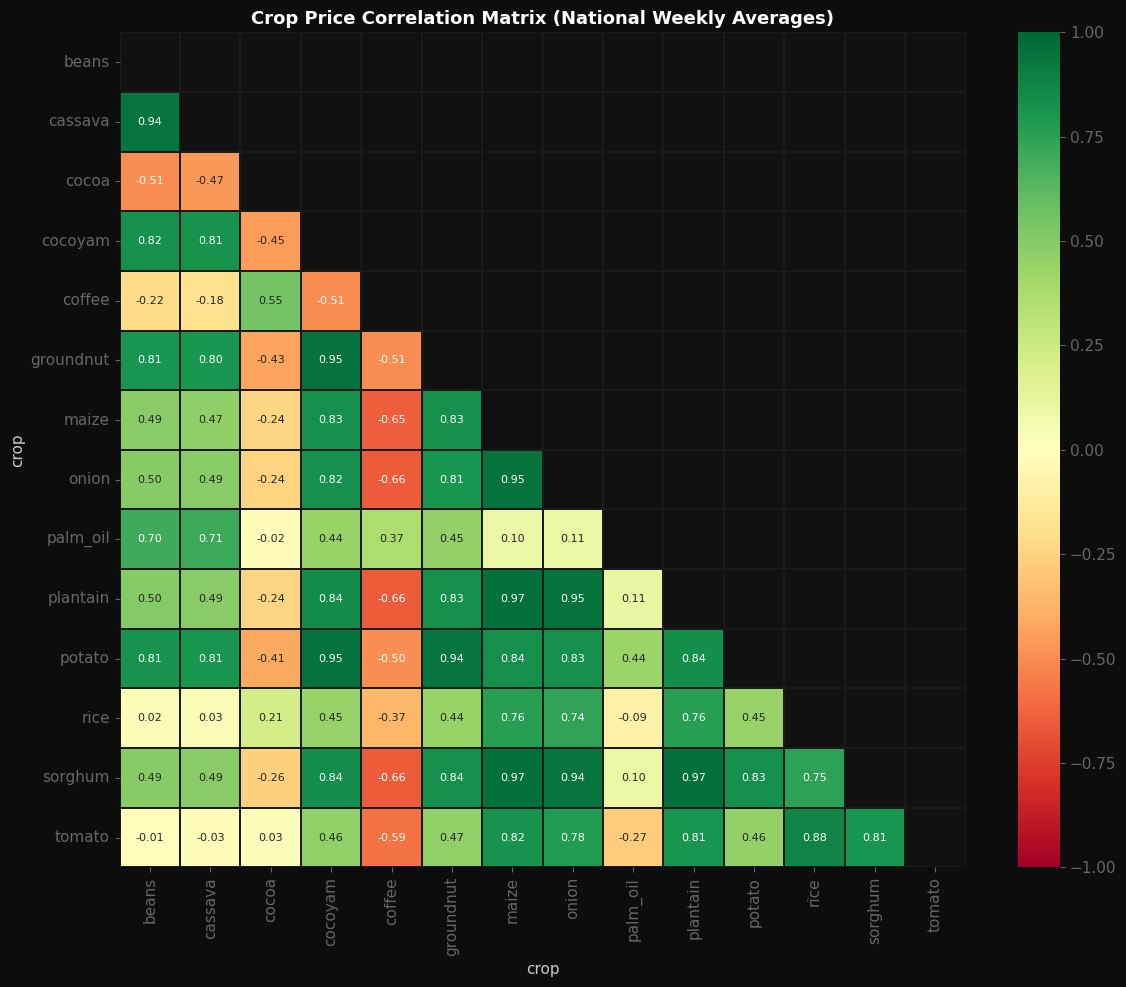


Strongest positive correlations (>0.7):
crop       crop     
sorghum    maize        0.967819
           plantain     0.967818
plantain   maize        0.967505
onion      maize        0.951320
groundnut  cocoyam      0.950585
plantain   onion        0.950343
potato     cocoyam      0.947714
           groundnut    0.944481
cassava    beans        0.943659
sorghum    onion        0.938070
dtype: float64


In [11]:
# ── 2.8 Price correlation matrix (national averages) ──────────────────────
price_wide = (
    prices.groupby(['date','crop'])['price_xaf_per_kg']
    .mean()
    .unstack('crop')
)
corr = price_wide.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr, mask=mask, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, linewidths=0.3, linecolor='#1a1a1a',
    annot_kws={'size': 8}
)
ax.set_title('Crop Price Correlation Matrix (National Weekly Averages)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'price_correlation_matrix.png', dpi=140, bbox_inches='tight')
plt.show()

print('\nStrongest positive correlations (>0.7):')
corr_vals = corr.where(mask == False).stack()
print(corr_vals[corr_vals > 0.7].sort_values(ascending=False).head(10))

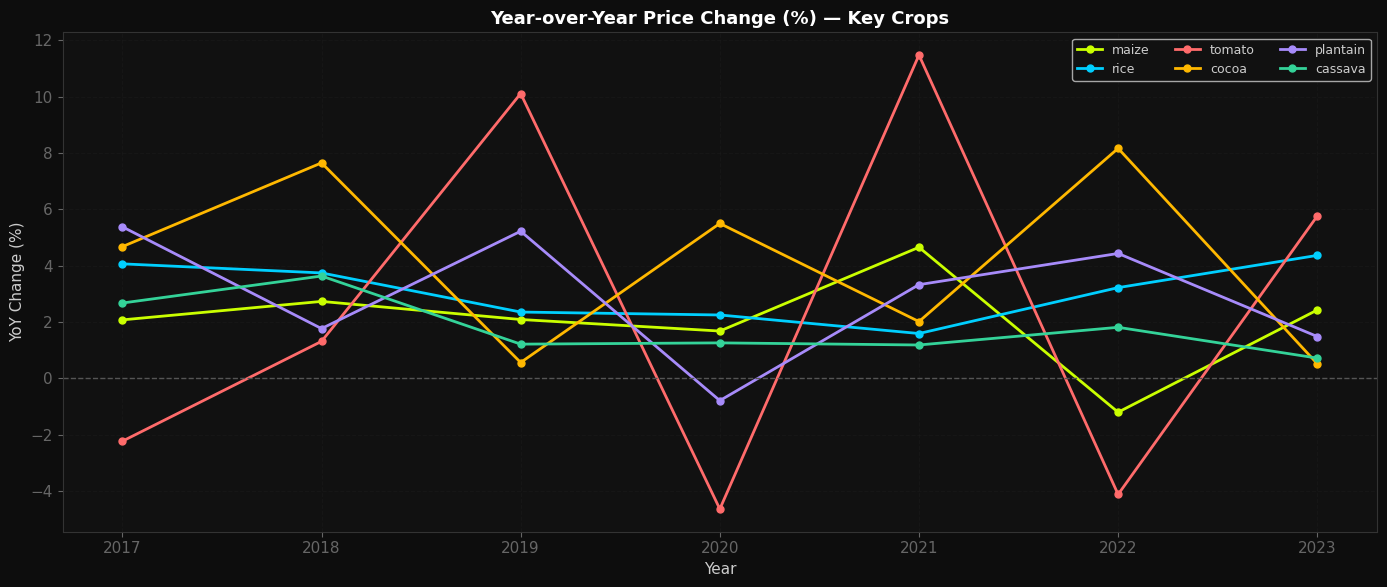

In [12]:
# ── 2.9 Year-over-year price change ───────────────────────────────────────
yoy = (
    prices.groupby(['year','crop'])['price_xaf_per_kg']
    .mean()
    .reset_index()
    .pivot(index='year', columns='crop', values='price_xaf_per_kg')
    .pct_change() * 100
)

fig, ax = plt.subplots(figsize=(14, 6))
for crop, c in zip(KEY_CROPS, PALETTE):
    ax.plot(yoy.index, yoy[crop], marker='o', markersize=5, lw=2, color=c, label=crop)
ax.axhline(0, color='#555555', lw=1, linestyle='--')
ax.set_title('Year-over-Year Price Change (%) — Key Crops')
ax.set_xlabel('Year'); ax.set_ylabel('YoY Change (%)')
ax.legend(ncol=3, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'price_yoy_change.png', dpi=140, bbox_inches='tight')
plt.show()

## 3. Yield Data EDA

In [13]:
# ── 3.1 Yield schema & quality checks ─────────────────────────────────────
print('=== YIELD DATA SCHEMA ===')
print(yields.dtypes)
print()
print('=== MISSING VALUES ===')
print(yields.isnull().sum())
print()
print('=== DESCRIPTIVE STATISTICS ===')
print(yields.describe().round(3))

=== YIELD DATA SCHEMA ===
crop                  object
region                object
land_size_ha         float64
soil_ph              float64
rainfall_mm            int64
temperature_c        float64
humidity_pct         float64
elevation_m            int64
irrigation             int64
fertilizer_type       object
yield_tons_per_ha    float64
total_yield_tons     float64
year                   int64
dtype: object

=== MISSING VALUES ===
crop                 0
region               0
land_size_ha         0
soil_ph              0
rainfall_mm          0
temperature_c        0
humidity_pct         0
elevation_m          0
irrigation           0
fertilizer_type      0
yield_tons_per_ha    0
total_yield_tons     0
year                 0
dtype: int64

=== DESCRIPTIVE STATISTICS ===
       land_size_ha   soil_ph  rainfall_mm  temperature_c  humidity_pct  \
count      3000.000  3000.000     3000.000       3000.000      3000.000   
mean         25.330     6.040     1712.669         25.031        

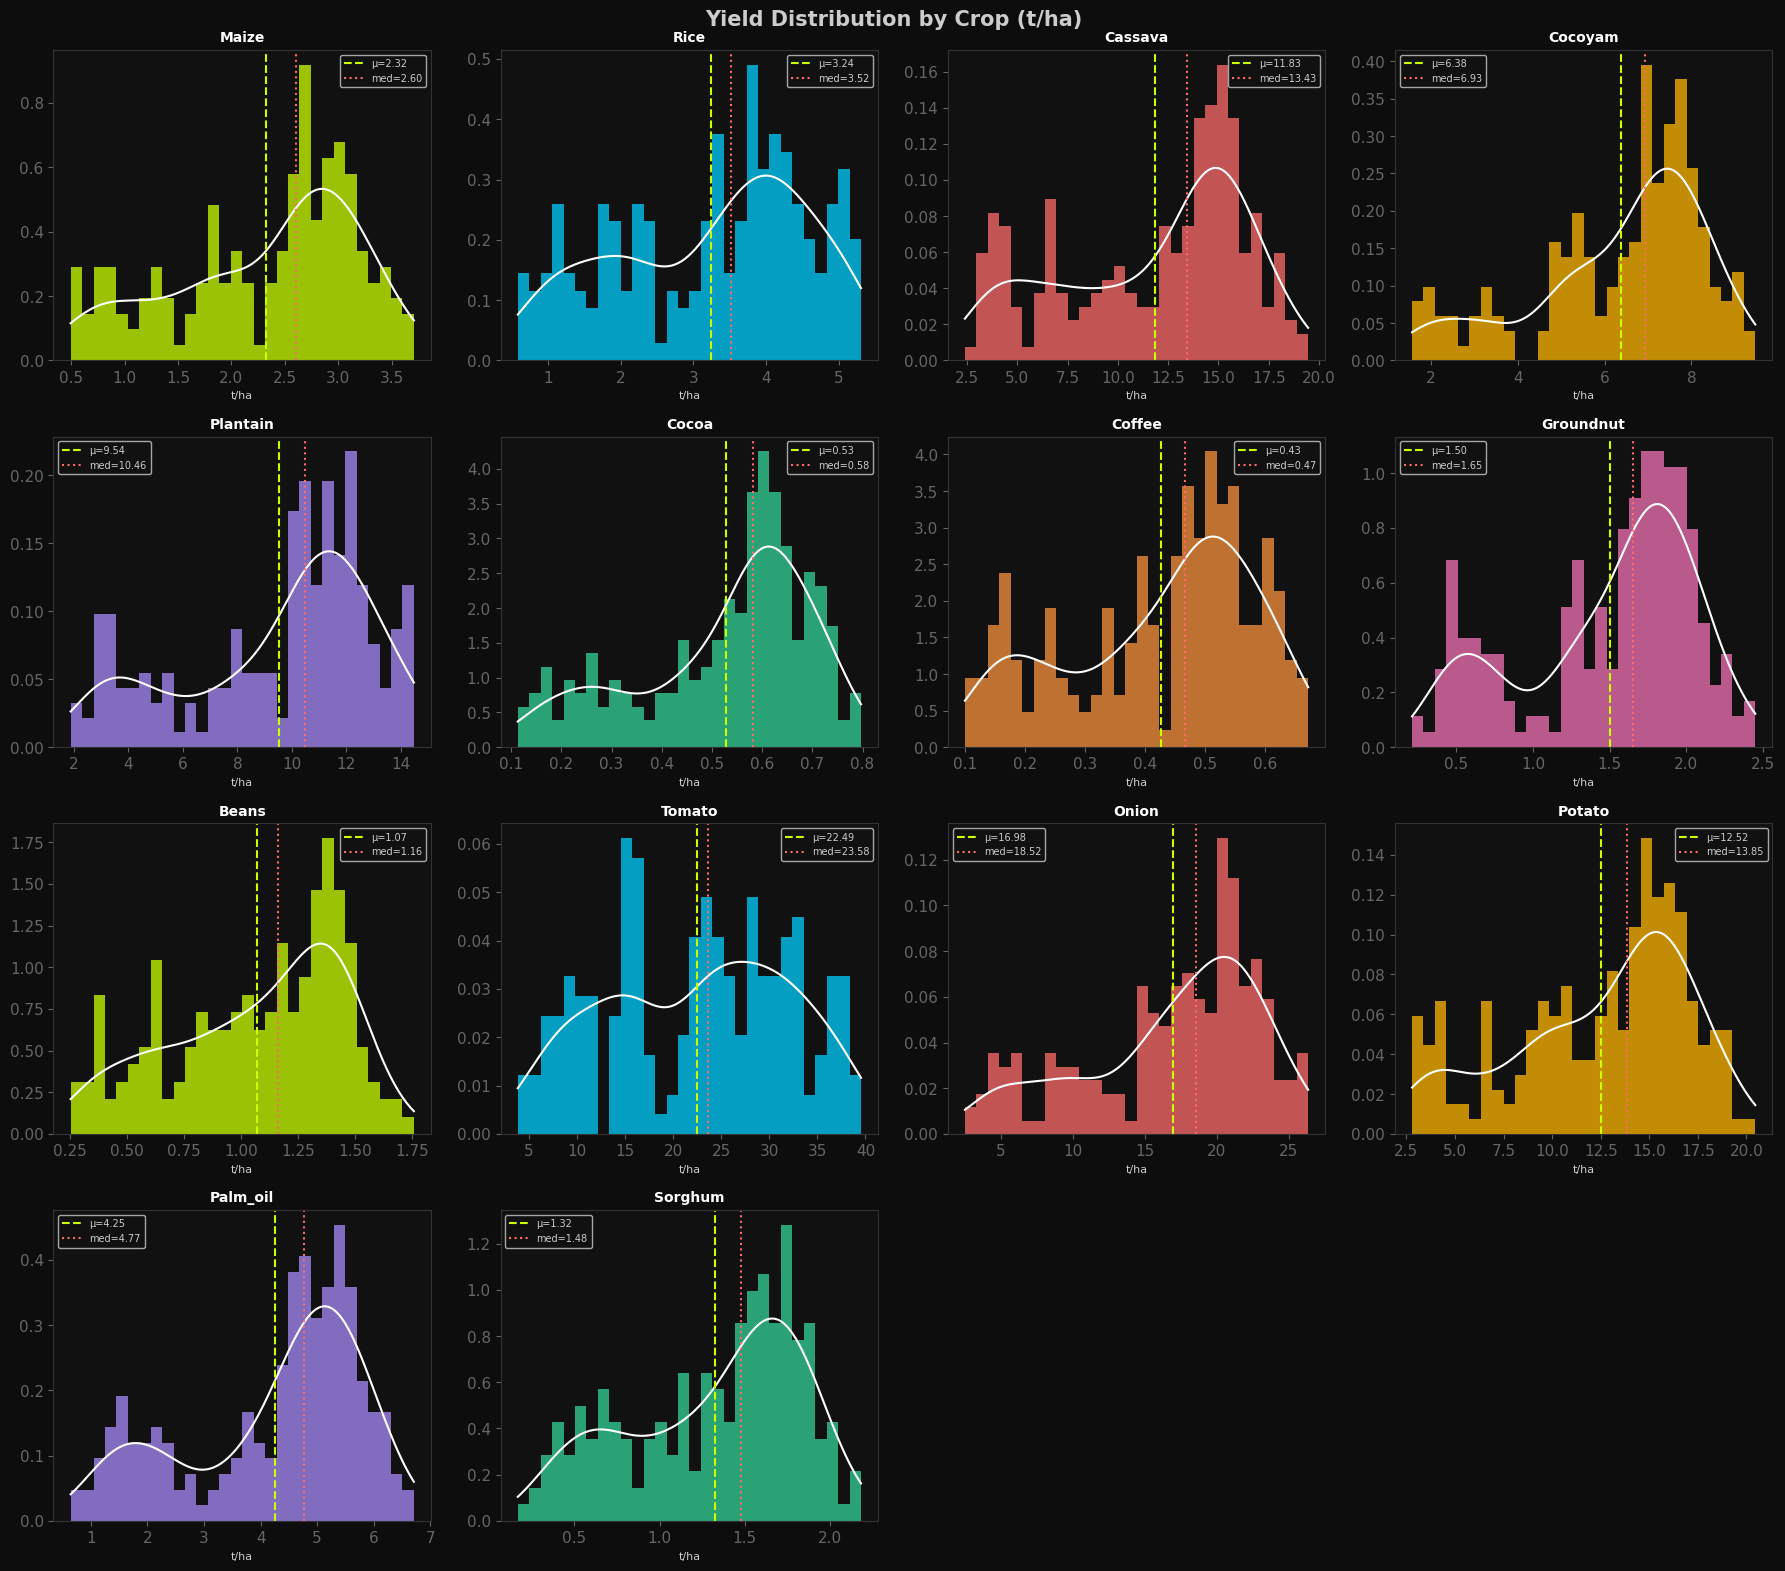

In [14]:
# ── 3.2 Yield distribution by crop ────────────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
for ax, (crop, c) in zip(axes.flat[:14], zip(CROPS, PALETTE * 2)):
    data = yields.loc[yields.crop == crop, 'yield_tons_per_ha']
    ax.hist(data, bins=30, color=c, alpha=0.75, edgecolor='none', density=True)
    # KDE overlay
    kde_x = np.linspace(data.min(), data.max(), 200)
    kde   = stats.gaussian_kde(data)
    ax.plot(kde_x, kde(kde_x), color='white', lw=1.5)
    ax.axvline(data.mean(),   color=LIME,      lw=1.5, linestyle='--', label=f'μ={data.mean():.2f}')
    ax.axvline(data.median(), color='#FF6B6B', lw=1.5, linestyle=':',  label=f'med={data.median():.2f}')
    ax.set_title(f'{crop.capitalize()}', fontsize=10)
    ax.set_xlabel('t/ha', fontsize=8); ax.legend(fontsize=7)
for ax in axes.flat[14:]: ax.set_visible(False)
fig.suptitle('Yield Distribution by Crop (t/ha)', fontsize=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'yield_distribution.png', dpi=140, bbox_inches='tight')
plt.show()

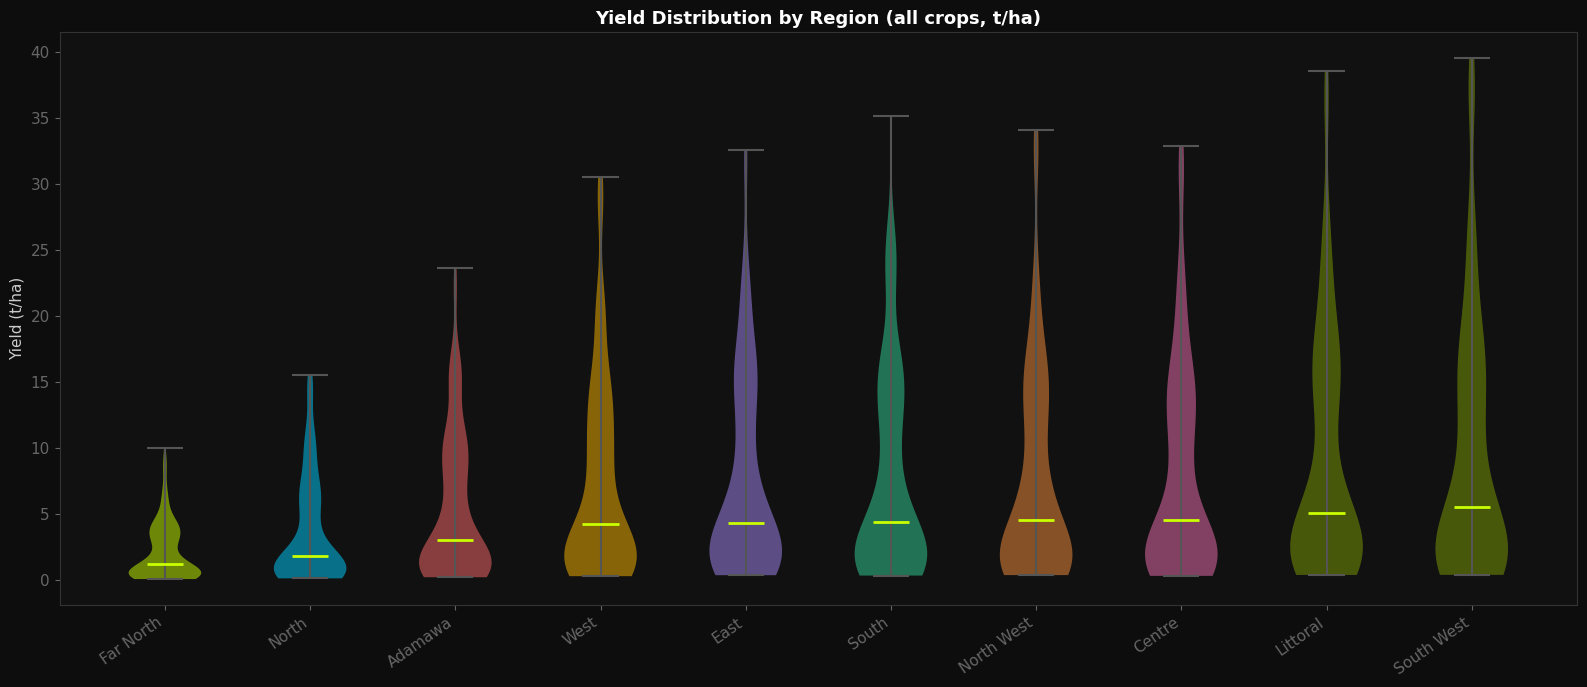

In [15]:
# ── 3.3 Yield by region (violin plot) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
region_order = yields.groupby('region')['yield_tons_per_ha'].median().sort_values().index
parts = ax.violinplot(
    [yields.loc[yields.region==r,'yield_tons_per_ha'].values for r in region_order],
    showmedians=True, showmeans=False,
)
for pc, c in zip(parts['bodies'], PALETTE):
    pc.set_facecolor(c); pc.set_alpha(0.5)
parts['cmedians'].set_color(LIME); parts['cmedians'].set_linewidth(2)
for key in ['cbars','cmins','cmaxes']: parts[key].set_color('#555555')
ax.set_xticks(range(1, len(region_order)+1))
ax.set_xticklabels(region_order, rotation=35, ha='right')
ax.set_title('Yield Distribution by Region (all crops, t/ha)')
ax.set_ylabel('Yield (t/ha)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'yield_by_region.png', dpi=140, bbox_inches='tight')
plt.show()

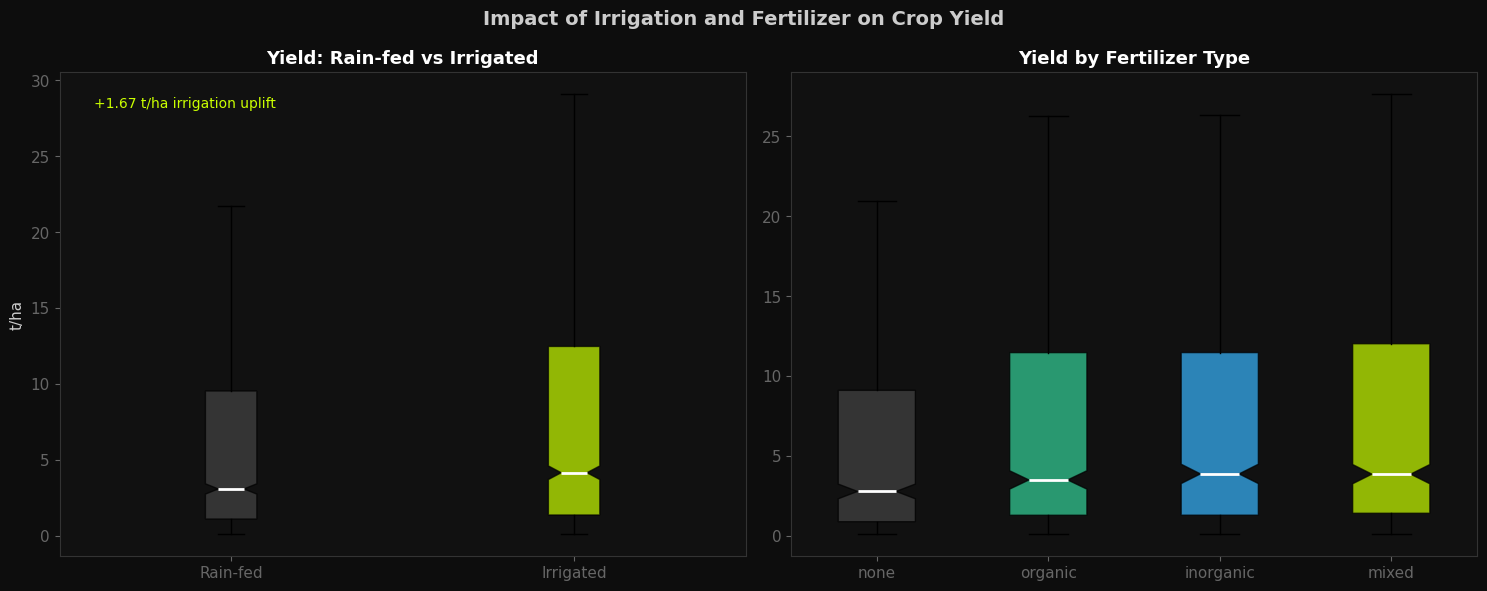


Mean yields by fertilizer type:
fertilizer_type
inorganic    7.080
mixed        7.419
none         5.846
organic      6.813
Name: yield_tons_per_ha, dtype: float64


In [16]:
# ── 3.4 Irrigation & fertilizer impact on yield ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Irrigation
irr_data = [
    yields.loc[yields.irrigation==0,'yield_tons_per_ha'],
    yields.loc[yields.irrigation==1,'yield_tons_per_ha'],
]
bp1 = axes[0].boxplot(irr_data, labels=['Rain-fed','Irrigated'],
                      patch_artist=True, showfliers=False, notch=True)
for patch, c in zip(bp1['boxes'], ['#444444', LIME]):
    patch.set_facecolor(c); patch.set_alpha(0.7)
for med in bp1['medians']: med.set_color('white'); med.set_linewidth(2)
axes[0].set_title('Yield: Rain-fed vs Irrigated'); axes[0].set_ylabel('t/ha')
# mean difference
diff = irr_data[1].mean() - irr_data[0].mean()
axes[0].text(0.05, 0.95, f'+{diff:.2f} t/ha irrigation uplift',
             transform=axes[0].transAxes, color=LIME, fontsize=10, va='top')

# Fertilizer
fert_order = ['none','organic','inorganic','mixed']
fert_data  = [yields.loc[yields.fertilizer_type==f,'yield_tons_per_ha'] for f in fert_order]
bp2 = axes[1].boxplot(fert_data, labels=fert_order,
                      patch_artist=True, showfliers=False, notch=True)
for patch, c in zip(bp2['boxes'], ['#444444','#34D399','#38B6FF',LIME]):
    patch.set_facecolor(c); patch.set_alpha(0.7)
for med in bp2['medians']: med.set_color('white'); med.set_linewidth(2)
axes[1].set_title('Yield by Fertilizer Type')

plt.suptitle('Impact of Irrigation and Fertilizer on Crop Yield', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'yield_irrigation_fertilizer.png', dpi=140, bbox_inches='tight')
plt.show()

print('\nMean yields by fertilizer type:')
print(yields.groupby('fertilizer_type')['yield_tons_per_ha'].mean().round(3))

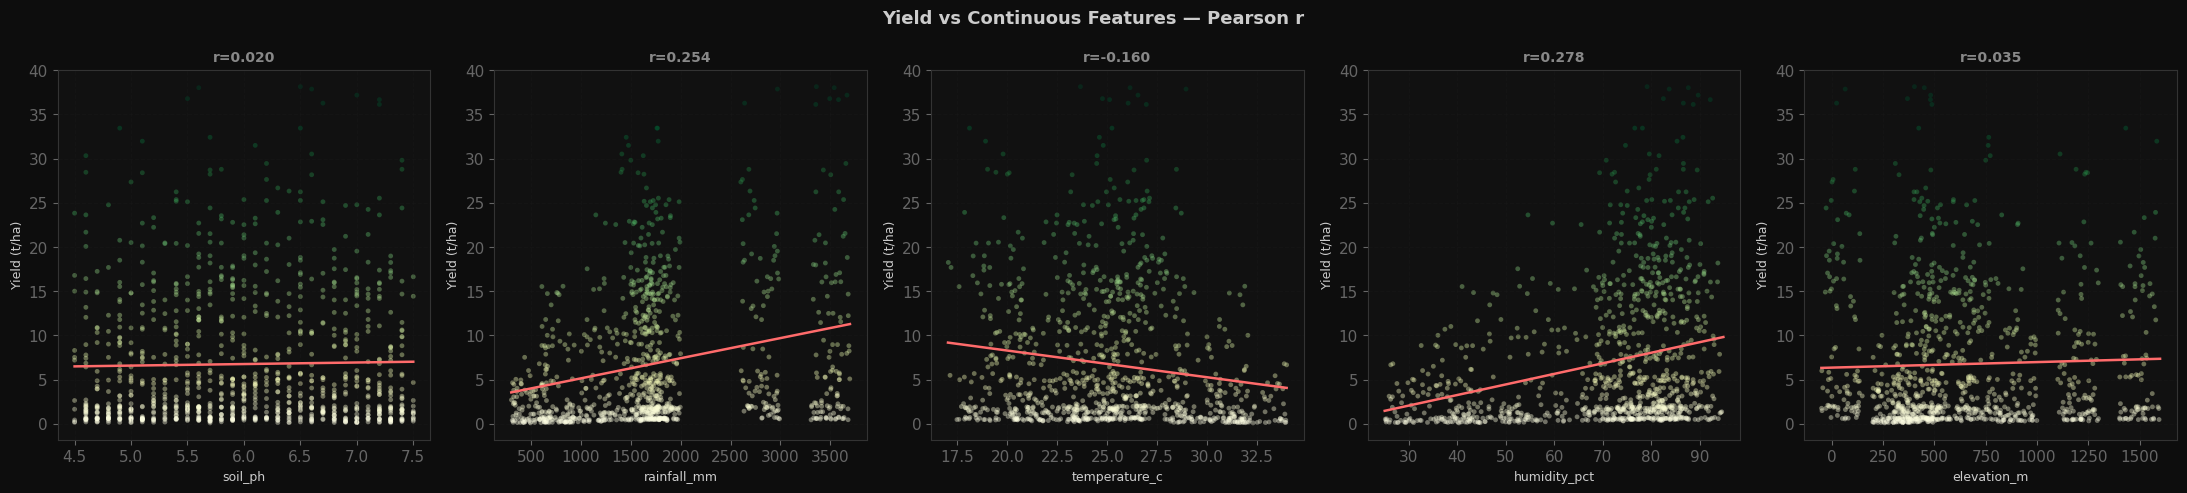

In [17]:
# ── 3.5 Yield vs continuous features (scatter matrix) ─────────────────────
numeric_feats = ['soil_ph','rainfall_mm','temperature_c','humidity_pct','elevation_m']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, feat in zip(axes, numeric_feats):
    # Sample for speed
    sample = yields.sample(min(1000, len(yields)), random_state=42)
    sc = ax.scatter(sample[feat], sample['yield_tons_per_ha'],
                    c=sample['yield_tons_per_ha'], cmap='YlGn',
                    alpha=0.4, s=12, edgecolors='none')
    # Regression line
    m, b, r, p, _ = stats.linregress(yields[feat], yields['yield_tons_per_ha'])
    x_line = np.linspace(yields[feat].min(), yields[feat].max(), 100)
    ax.plot(x_line, m*x_line + b, color='#FF6B6B', lw=1.8)
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('Yield (t/ha)', fontsize=9)
    ax.set_title(f'r={r:.3f}', fontsize=10,
                 color=LIME if abs(r)>0.3 else '#888888')
    ax.grid(True, alpha=0.2)

fig.suptitle('Yield vs Continuous Features — Pearson r', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'yield_scatter_features.png', dpi=140, bbox_inches='tight')
plt.show()

In [18]:
# ── 3.6 Skewness & kurtosis of yield per crop ─────────────────────────────
shape_stats = (
    yields.groupby('crop')['yield_tons_per_ha']
    .agg(skewness=skew, excess_kurtosis=kurtosis)
    .round(3)
    .sort_values('skewness')
)
print('=== YIELD DISTRIBUTION SHAPE (per crop) ===')
print(shape_stats.to_string())
print()
print('Crops with high skewness (|skew|>1) may need log-transform before modelling:')
print(shape_stats[abs(shape_stats.skewness) > 1].index.tolist())

=== YIELD DISTRIBUTION SHAPE (per crop) ===
           skewness  excess_kurtosis
crop                                
cocoyam      -0.907           -0.019
cocoa        -0.790           -0.389
palm_oil     -0.759           -0.633
onion        -0.738           -0.441
plantain     -0.717           -0.631
groundnut    -0.688           -0.645
potato       -0.611           -0.646
maize        -0.589           -0.735
coffee       -0.543           -0.859
cassava      -0.536           -0.985
sorghum      -0.519           -0.887
beans        -0.501           -0.842
rice         -0.365           -1.048
tomato       -0.133           -1.104

Crops with high skewness (|skew|>1) may need log-transform before modelling:
[]


## 4. Soil Data EDA

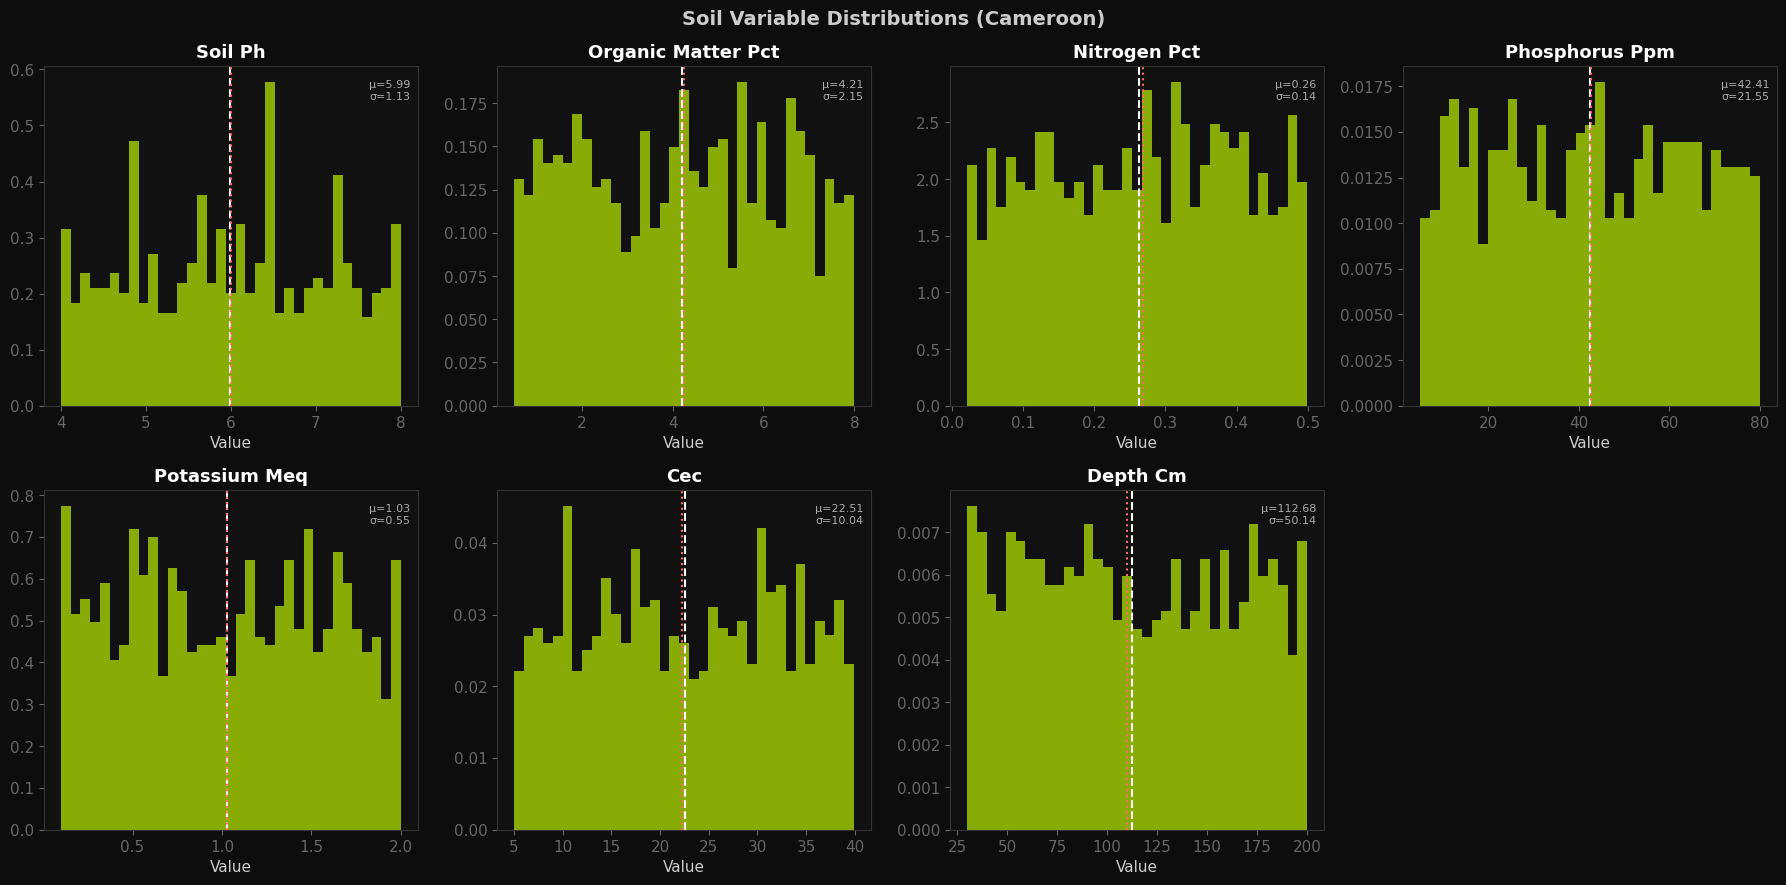

In [19]:
# ── 4.1 Soil variable distributions ───────────────────────────────────────
soil_numeric = ['soil_ph','organic_matter_pct','nitrogen_pct',
                'phosphorus_ppm','potassium_meq','cec','depth_cm']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, feat in zip(axes.flat, soil_numeric):
    ax.hist(soil[feat], bins=35, color=LIME, alpha=0.65, edgecolor='none', density=True)
    ax.axvline(soil[feat].mean(),   color='white',   lw=1.5, linestyle='--')
    ax.axvline(soil[feat].median(), color='#FF6B6B', lw=1.5, linestyle=':')
    ax.set_title(feat.replace('_',' ').title()); ax.set_xlabel('Value')
    ax.text(0.98, 0.96, f'μ={soil[feat].mean():.2f}\nσ={soil[feat].std():.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8, color='#aaaaaa')
axes.flat[-1].set_visible(False)
fig.suptitle('Soil Variable Distributions (Cameroon)', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'soil_distributions.png', dpi=140, bbox_inches='tight')
plt.show()

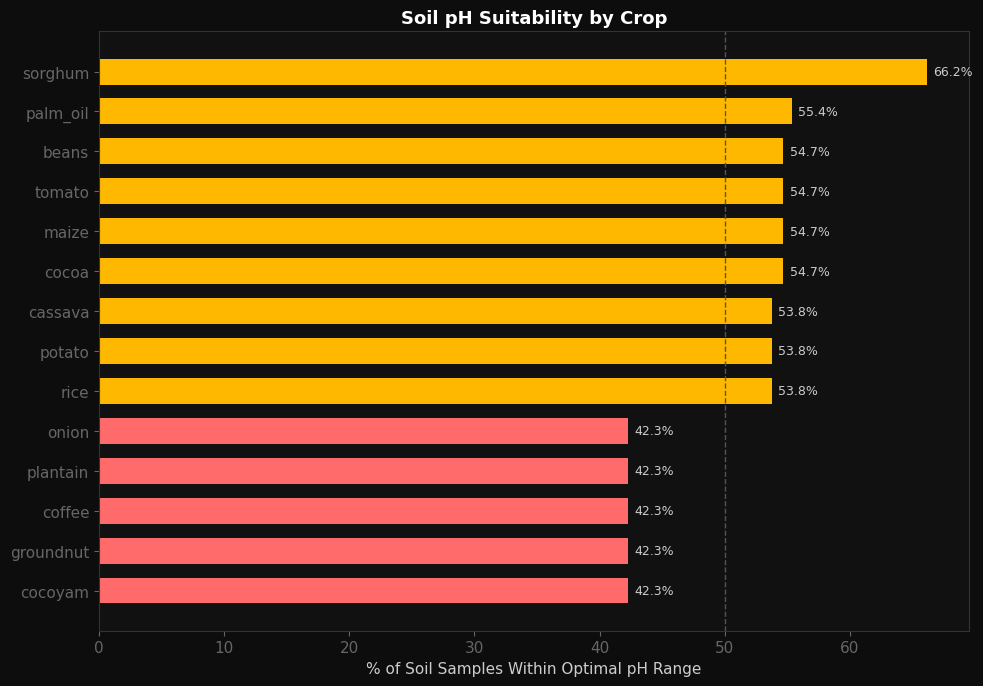

In [20]:
# ── 4.2 Soil pH suitability for crops ─────────────────────────────────────
# Optimal pH ranges by crop (agronomic literature)
crop_ph_ranges = {
    'maize':(5.5,7.5),'rice':(5.0,7.0),'cassava':(5.0,7.0),'cocoyam':(5.5,7.0),
    'plantain':(5.5,7.0),'cocoa':(5.5,7.5),'coffee':(5.5,7.0),'groundnut':(5.5,7.0),
    'beans':(5.5,7.5),'tomato':(5.5,7.5),'onion':(5.5,7.0),'potato':(5.0,7.0),
    'palm_oil':(4.5,6.5),'sorghum':(5.0,7.5),
}
ph_vals = soil['soil_ph']
suitability = {}
for crop,(lo,hi) in crop_ph_ranges.items():
    suitable_pct = ((ph_vals>=lo) & (ph_vals<=hi)).mean() * 100
    suitability[crop] = suitable_pct

suit_s = pd.Series(suitability).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(suit_s.index, suit_s.values,
               color=[LIME if v>70 else '#FFB800' if v>50 else '#FF6B6B' for v in suit_s.values],
               edgecolor='none', height=0.65)
ax.axvline(50, color='#555555', lw=1, linestyle='--')
ax.set_xlabel('% of Soil Samples Within Optimal pH Range')
ax.set_title('Soil pH Suitability by Crop')
for bar, v in zip(bars, suit_s.values):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'soil_ph_suitability.png', dpi=140, bbox_inches='tight')
plt.show()

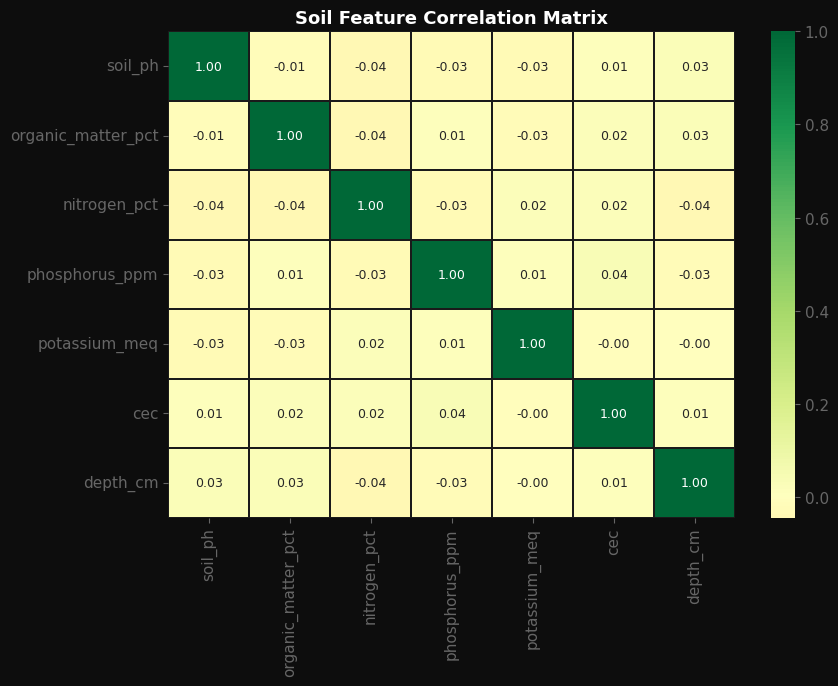


Soil type distribution:
soil_type
Sandy loam    182
Clay          180
Silty clay    166
Loam          164
Sandy clay    163
Laterite      145
Name: count, dtype: int64

Drainage distribution:
drainage
excessive    274
poor         259
moderate     244
good         223
Name: count, dtype: int64


In [21]:
# ── 4.3 Soil correlation heatmap ──────────────────────────────────────────
soil_corr = soil[soil_numeric].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(soil_corr, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.3, linecolor='#1a1a1a', annot_kws={'size':9})
ax.set_title('Soil Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'soil_correlation.png', dpi=140, bbox_inches='tight')
plt.show()

print('\nSoil type distribution:')
print(soil['soil_type'].value_counts())
print('\nDrainage distribution:')
print(soil['drainage'].value_counts())

## 5. Climate Data EDA

In [29]:
# ── 5.1 Temperature & rainfall by region ──────────────────────────────────
climate_means = climate.groupby('region')[['avg_temp_c','rainfall_mm','humidity_pct']].mean()
print('=== MEAN CLIMATE CONDITIONS BY REGION ===')
print(climate_means.round(2).to_string())

=== MEAN CLIMATE CONDITIONS BY REGION ===
           avg_temp_c  rainfall_mm  humidity_pct
region                                          
Center          24.57       172.80         76.02
Far North       31.45        84.42         40.18
Littoral        26.40       395.53         85.54
North           31.47        82.58         40.28
West            21.73       168.99         76.42


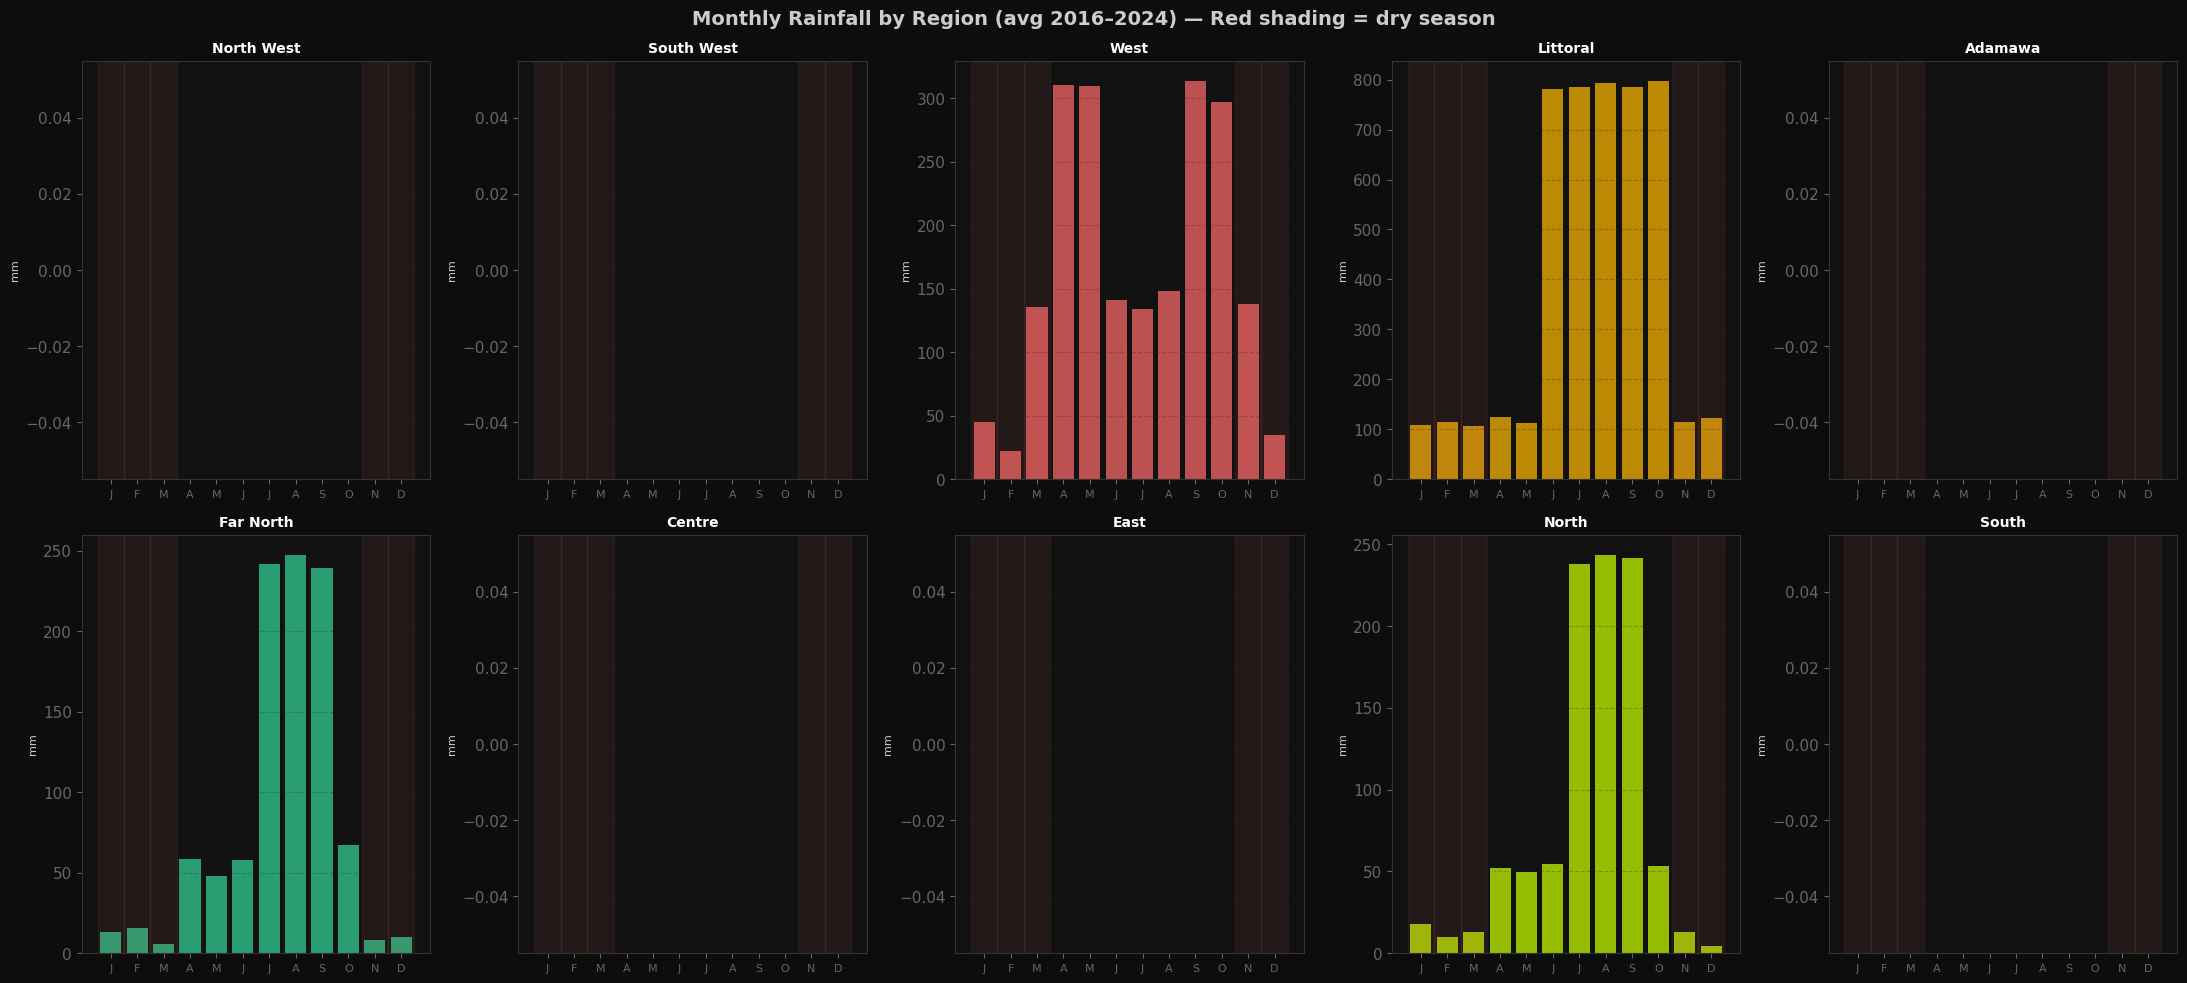

In [30]:
# ── 5.2 Rainfall seasonality by region ────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
for ax, (reg, c) in zip(axes.flat, zip(REGIONS, PALETTE*2)):
    df = climate[climate.region==reg].groupby('month')['rainfall_mm'].mean()
    ax.bar(df.index, df.values, color=c, alpha=0.72, edgecolor='none')
    ax.set_xticks(range(1,13)); ax.set_xticklabels(month_labels, fontsize=8)
    ax.set_title(reg, fontsize=10)
    ax.set_ylabel('mm', fontsize=8); ax.grid(True, axis='y', alpha=0.25)
    # Highlight dry season
    for mo in [11,12,1,2,3]: ax.axvspan(mo-0.5, mo+0.5, alpha=0.08, color='#FF6B6B')
fig.suptitle('Monthly Rainfall by Region (avg 2016–2024) — Red shading = dry season', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'climate_rainfall_seasonality.png', dpi=140, bbox_inches='tight')
plt.show()

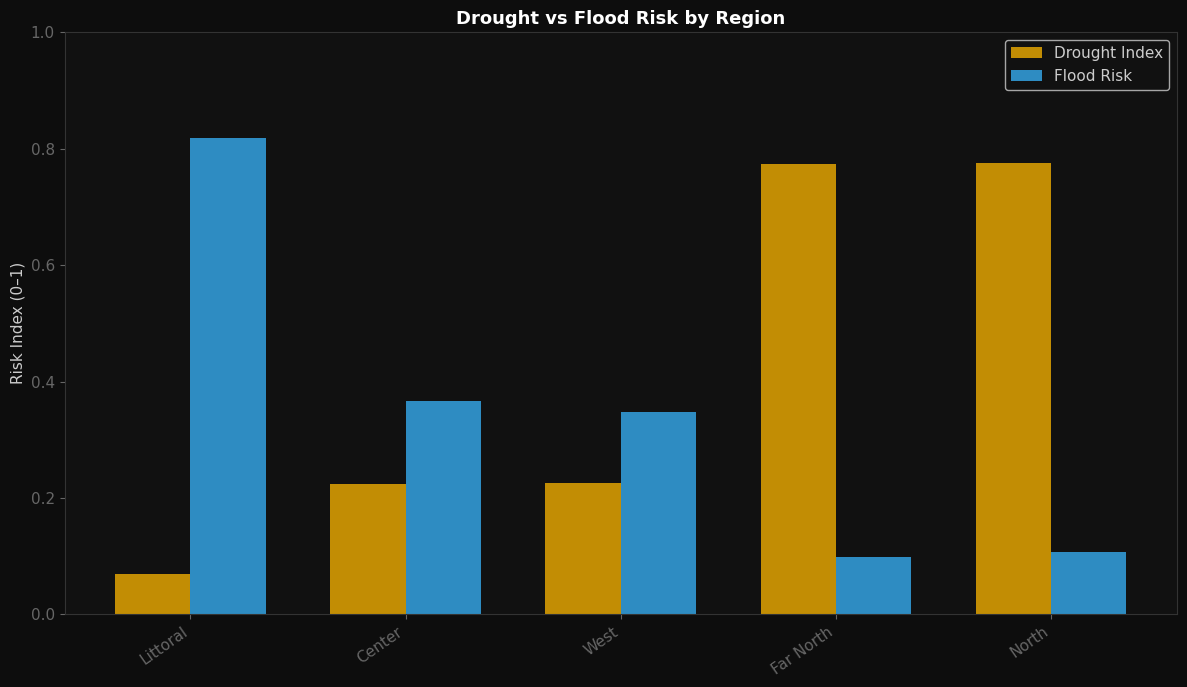

In [31]:
# ── 5.3 Drought & flood risk by region ────────────────────────────────────
risk_df = climate.groupby('region')[['drought_index','flood_risk']].mean().sort_values('drought_index')

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(risk_df))
w = 0.35
b1 = ax.bar(x - w/2, risk_df['drought_index'], w, label='Drought Index',
            color='#FFB800', alpha=0.75, edgecolor='none')
b2 = ax.bar(x + w/2, risk_df['flood_risk'],    w, label='Flood Risk',
            color='#38B6FF', alpha=0.75, edgecolor='none')
ax.set_xticks(x); ax.set_xticklabels(risk_df.index, rotation=35, ha='right')
ax.set_ylabel('Risk Index (0–1)'); ax.set_title('Drought vs Flood Risk by Region')
ax.legend(); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'climate_risk_by_region.png', dpi=140, bbox_inches='tight')
plt.show()

## 6. Cross-Dataset Correlations

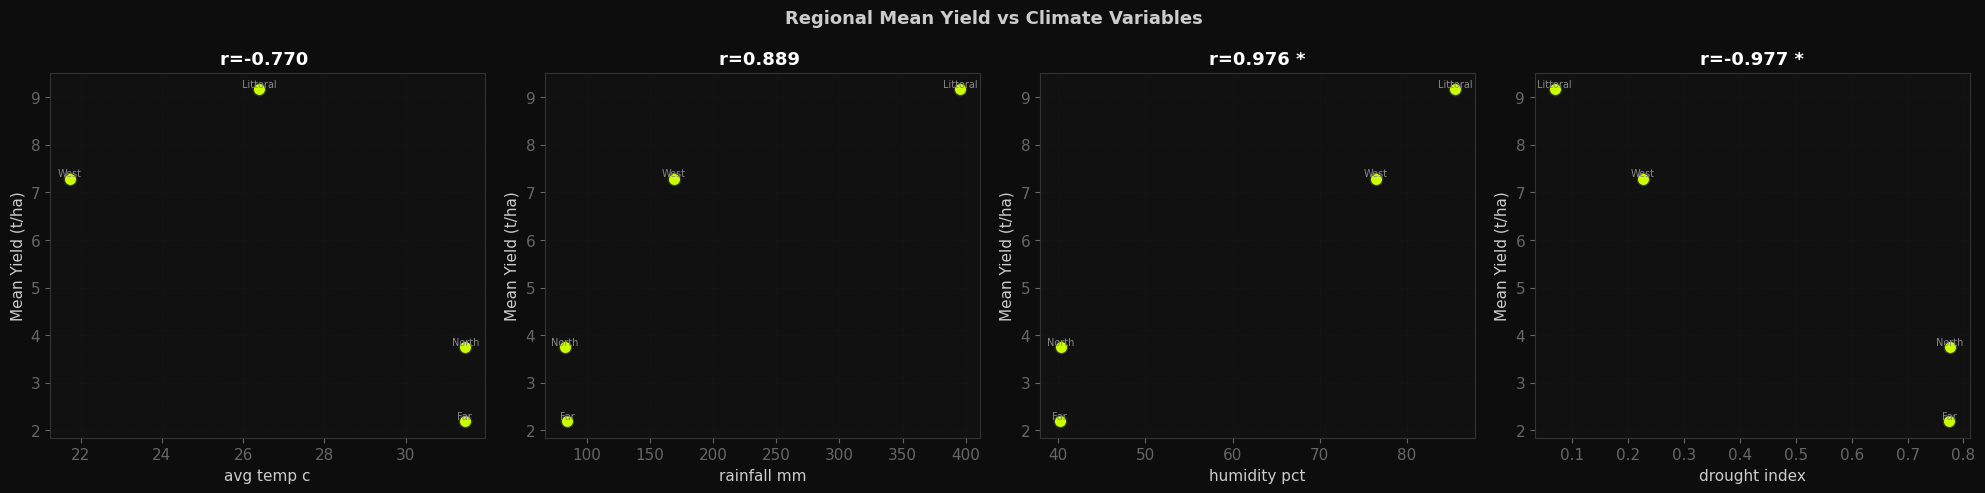

In [32]:
# ── 6.1 Merge climate with yield by region ────────────────────────────────
clim_region = climate.groupby('region')[['avg_temp_c','rainfall_mm','humidity_pct','drought_index']].mean().reset_index()
yield_region = yields.groupby('region')['yield_tons_per_ha'].mean().reset_index()
merged = yield_region.merge(clim_region, on='region')

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, feat in zip(axes, ['avg_temp_c','rainfall_mm','humidity_pct','drought_index']):
    ax.scatter(merged[feat], merged['yield_tons_per_ha'],
               c=LIME, s=80, edgecolors='#333333', zorder=3)
    for _, row in merged.iterrows():
        ax.annotate(row.region.split()[0],
                    (row[feat], row['yield_tons_per_ha']),
                    fontsize=7, color='#888888', ha='center', va='bottom')
    r, p = stats.pearsonr(merged[feat], merged['yield_tons_per_ha'])
    ax.set_xlabel(feat.replace('_',' ')); ax.set_ylabel('Mean Yield (t/ha)')
    ax.set_title(f'r={r:.3f} {"*" if p<0.05 else ""}')
    ax.grid(True, alpha=0.2)
fig.suptitle('Regional Mean Yield vs Climate Variables', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'cross_yield_climate.png', dpi=140, bbox_inches='tight')
plt.show()

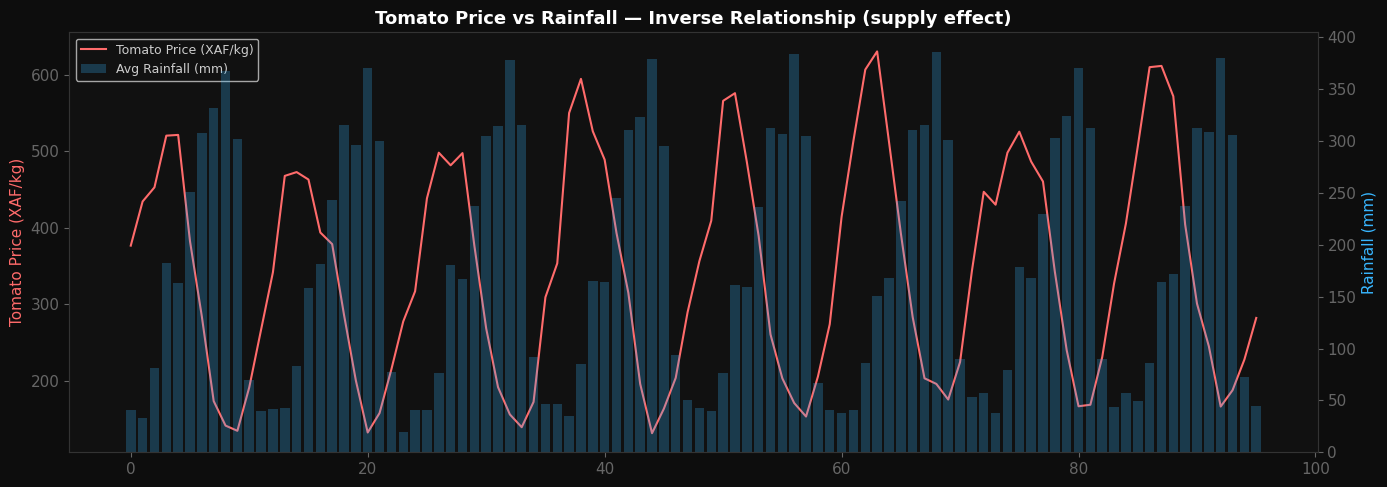

Pearson r (tomato price vs rainfall): -0.5238  (p=0.0000)


In [33]:
# ── 6.2 Price vs rainfall (tomato — high seasonal variability) ────────────
tomato_prices = (
    prices[prices.crop=='tomato']
    .groupby(['year','month'])['price_xaf_per_kg'].mean()
    .reset_index()
)
# National average rainfall
nat_rain = climate.groupby(['year','month'])['rainfall_mm'].mean().reset_index()
merged_t = tomato_prices.merge(nat_rain, on=['year','month'])

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(range(len(merged_t)), merged_t['price_xaf_per_kg'], color='#FF6B6B', lw=1.5, label='Tomato Price (XAF/kg)')
ax2 = ax1.twinx()
ax2.bar(range(len(merged_t)), merged_t['rainfall_mm'], color='#38B6FF', alpha=0.25, label='Avg Rainfall (mm)')
ax2.set_ylabel('Rainfall (mm)', color='#38B6FF')
ax1.set_ylabel('Tomato Price (XAF/kg)', color='#FF6B6B')
ax1.set_title('Tomato Price vs Rainfall — Inverse Relationship (supply effect)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'cross_tomato_price_rainfall.png', dpi=140, bbox_inches='tight')
plt.show()

r, p = stats.pearsonr(merged_t['price_xaf_per_kg'], merged_t['rainfall_mm'])
print(f'Pearson r (tomato price vs rainfall): {r:.4f}  (p={p:.4f})')

## 7. Key Findings Summary

In [35]:
# ── 7.1 Print structured findings ─────────────────────────────────────────
print('=' * 65)
print('  CAMAGRI EDA — KEY FINDINGS')
print('=' * 65)

print('\n[PRICES]')
most_volatile = vol['cv'].idxmax()
least_volatile= vol['cv'].idxmin()
print(f'  Most volatile crop : {most_volatile} (CV={vol.loc[most_volatile,"cv"]:.1f}%)')
print(f'  Least volatile crop: {least_volatile} (CV={vol.loc[least_volatile,"cv"]:.1f}%)')

print('\n[YIELDS]')
top_yield = yields.groupby('crop')['yield_tons_per_ha'].mean().idxmax()
irr_lift  = (yields.loc[yields.irrigation==1,'yield_tons_per_ha'].mean() /
             yields.loc[yields.irrigation==0,'yield_tons_per_ha'].mean() - 1) * 100
print(f'  Highest yielding crop: {top_yield}')
print(f'  Irrigation yield uplift: +{irr_lift:.1f}% on average')
print(f'  Fertilizer uplift (organic): +{(yields.loc[yields.fertilizer_type=="organic","yield_tons_per_ha"].mean() / yields.loc[yields.fertilizer_type=="none","yield_tons_per_ha"].mean()-1)*100:.1f}%')

print('\n[SOIL]')
print(f'  Most common soil type : {soil["soil_type"].mode()[0]}')
print(f'  pH range (5th-95th)  : {soil["soil_ph"].quantile(.05):.1f} – {soil["soil_ph"].quantile(.95):.1f}')
print(f'  % acidic soils (pH<5.5): {(soil["soil_ph"]<5.5).mean()*100:.1f}%')

print('\n[CLIMATE]')
highest_rain = climate.groupby('region')['rainfall_mm'].sum().idxmax()
lowest_rain  = climate.groupby('region')['rainfall_mm'].sum().idxmin()
print(f'  Highest rainfall region: {highest_rain}')
print(f'  Lowest rainfall region : {lowest_rain} (drought risk)')
print(f'  Highest drought index  : {climate.groupby("region")["drought_index"].mean().idxmax()}')

print('\n[MODELLING IMPLICATIONS]')
print('  - Price models: use seasonal + trend decomposition; consider ARIMA/Prophet')
print('  - Yield models: irrigation & fertilizer are strongest features')
print('  - Suitability : rainfall + elevation + pH drive crop selection')
print('  - Risk scoring: Far North highest climate risk; tomato highest financial risk')
print('=' * 65)

  CAMAGRI EDA — KEY FINDINGS

[PRICES]
  Most volatile crop : tomato (CV=43.1%)
  Least volatile crop: palm_oil (CV=14.6%)

[YIELDS]
  Highest yielding crop: tomato
  Irrigation yield uplift: +28.0% on average
  Fertilizer uplift (organic): +16.5%

[SOIL]
  Most common soil type : Sandy loam
  pH range (5th-95th)  : 4.2 – 7.8
  % acidic soils (pH<5.5): 35.1%

[CLIMATE]
  Highest rainfall region: Littoral
  Lowest rainfall region : North (drought risk)
  Highest drought index  : North

[MODELLING IMPLICATIONS]
  - Price models: use seasonal + trend decomposition; consider ARIMA/Prophet
  - Yield models: irrigation & fertilizer are strongest features
  - Suitability : rainfall + elevation + pH drive crop selection
  - Risk scoring: Far North highest climate risk; tomato highest financial risk
